<h1 style="text-align:center; font-size:40px;">
<b>Predicting CO2 Emissions from Cattle-Driven Deforestation in the Amazon Rainforest Using Machine Learning</b>
</h1>

Carlos Daniel Ambrosio 2022171

Suelen Rocha 2022345

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px

C:\Users\suele\anaconda4\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\suele\anaconda4\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


# EDA - Eploratory Data Analysis

# Data Understanding

Check dataset structure:

* Upload the datasets

* data type

* data description

* duplicate values

* shape (columns and rows)

* missing values

In [2]:
deforestation_df = pd.read_csv("prodes_amazon_legal.csv")
beef_df = pd.read_csv("beef_amazon.csv")
co2_df = pd.read_excel("inpe_EM_BRAmz_results.xlsx", sheet_name="Com degradação", skiprows=10)

In [3]:
deforestation_df. head()

,state,path_row,main_class,class_name,def_cloud,julian_day,image_date,year,area_km,scene_id,source,satellite,sensor,uuid
0,MT,22871,desmatamento,d2023,0.0,259,2023-09-16,2023,0.030756,10329.0,Amazonia - Nao Floresta,Sentinel-2,MSI,bd04328e-979a-4706-94e9-7b5a7ec2b15b
1,AP,22560,desmatamento,d2002,NaN,232,2002-08-20,2002,5.214920,NaN,Amazônia,LANDSAT8,OLI,68272938-3419-462c-b112-101c1ba38c6b
2,MT,22871,desmatamento,d2008,NaN,230,2008-08-17,2008,0.111416,NaN,Amazônia,LANDSAT8,OLI,84d395b0-999a-4319-854e-37f6370a7bae
3,MT,21016,desmatamento,d2024,0.0,256,2024-09-12,2024,0.013637,10610.0,Amazonia - Nao Floresta,Sentinel-2,MSI,cfc86599-70eb-4486-bea5-3186786b5039
4,AM,22962,desmatamento,d2004,NaN,290,2004-10-16,2004,0.144495,NaN,Amazônia,LANDSAT8,OLI,809bafdc-4dfd-45f7-8cd8-7490795d3391


In [4]:
beef_df.head()

,year,country_of_production,biome,state_of_production,state_of_production_trase_id,municipality_of_production,municipality_of_production_trase_id,logistics_hub,product_type,port_of_export,...,country_of_destination,economic_bloc,country_of_production_trase_id,country_of_destination_trase_id,cattle_deforestation_5_year_total_exposure,co2_gross_emissions_cattle_deforestation_5_year_total_exposure,co2_net_emissions_cattle_deforestation_5_year_total_exposure,land_use,volume,fob
0,2011,BRAZIL,AMAZONIA,ACRE,BR-12,BUJARI,BR-1200138,UNKNOWN,BEEF OFFALS,SANTOS,...,CHINA (HONG KONG),CHINA (HONG KONG),BR,HK,NaN,NaN,NaN,NaN,0.689217,2763.220500
1,2011,BRAZIL,AMAZONIA,ACRE,BR-12,RIO BRANCO,BR-1200401,UNKNOWN,BEEF OFFALS,SANTOS,...,CHINA (HONG KONG),CHINA (HONG KONG),BR,HK,NaN,NaN,NaN,NaN,0.975922,3912.684851
2,2011,BRAZIL,AMAZONIA,ACRE,BR-12,SENADOR GUIOMARD,BR-1200450,UNKNOWN,BEEF OFFALS,SANTOS,...,CHINA (HONG KONG),CHINA (HONG KONG),BR,HK,NaN,NaN,NaN,NaN,0.697649,2797.025472
3,2011,BRAZIL,AMAZONIA,AMAZONAS,BR-13,BOCA DO ACRE,BR-1300706,UNKNOWN,BEEF OFFALS,SANTOS,...,CHINA (HONG KONG),CHINA (HONG KONG),BR,HK,NaN,NaN,NaN,NaN,11.786114,39216.614533
4,2011,BRAZIL,AMAZONIA,AMAZONAS,BR-13,LABREA,BR-1302405,JARU,BEEF BONELESS,ITAJAA,...,RUSSIAN FEDERATION,RUSSIAN FEDERATION,BR,RU,NaN,NaN,NaN,NaN,1.119702,3395.156400


In [8]:
co2_df.head()

,Year,D_AreaAcc,D_Area,DEGRAD_Area,-,VR_CO2_1stOrder,VR_CO2_2ndOrder,SV_CO2Emission,SV_CO2Absorption,-.1,DEGRAD_CO2Emission,DEGRAD_CO2Absorption,-.2,NET_1st_Order,NET_2nd_Order
0,1960,842754,842754,0,-,411,133,0,0,-,0,0,-,411,133
1,1961,1685508,842754,0,-,411,222,0,0,-,0,0,-,411,222
2,1962,2528262,842754,0,-,411,276,0,0,-,0,0,-,411,276
3,1963,3371016,842754,0,-,411,311,0,-2,-,0,0,-,409,309
4,1964,4213770,842754,0,-,411,334,0,-4,-,0,0,-,407,329


In [9]:
deforestation_df.dtypes

state             str
path_row        int64
main_class        str
class_name        str
def_cloud     float64
julian_day      int64
image_date        str
year            int64
area_km       float64
scene_id      float64
source            str
satellite         str
sensor            str
uuid              str
dtype: object

In [11]:
beef_df.dtypes

year                                                                int64
country_of_production                                                 str
biome                                                                 str
state_of_production                                                   str
state_of_production_trase_id                                          str
municipality_of_production                                            str
municipality_of_production_trase_id                                   str
logistics_hub                                                         str
product_type                                                          str
port_of_export                                                        str
exporter                                                              str
exporter_group                                                        str
zero_deforestation_brazil_beef                                        str
forest_500_beef                       

In [12]:
co2_df.dtypes

Year                    int64
D_AreaAcc               int64
D_Area                  int64
DEGRAD_Area             int64
-                         str
VR_CO2_1stOrder         int64
VR_CO2_2ndOrder         int64
SV_CO2Emission          int64
SV_CO2Absorption        int64
-.1                       str
DEGRAD_CO2Emission      int64
DEGRAD_CO2Absorption    int64
-.2                       str
NET_1st_Order           int64
NET_2nd_Order           int64
dtype: object

In [13]:
deforestation_df.shape

(117177, 14)

In [14]:
beef_df.shape

(839727, 26)

In [15]:
co2_df.shape

(61, 15)

In [16]:
deforestation_df.duplicated().sum()

0

In [17]:
beef_df.duplicated().sum()

0

In [18]:
co2_df.duplicated().sum()

0

In [19]:
deforestation_df.isnull().values.any()

True

In [20]:
beef_df.isnull().values.any()

True

In [21]:
co2_df.isnull().values.any()

False

In [22]:
deforestation_df.isnull().sum()

state              0
path_row           0
main_class         0
class_name         0
def_cloud     107965
julian_day         0
image_date         0
year               0
area_km            0
scene_id      107988
source             0
satellite          0
sensor             0
uuid               0
dtype: int64

In [23]:
beef_df.isnull().sum()

year                                                                   0
country_of_production                                                  0
biome                                                                  0
state_of_production                                                    0
state_of_production_trase_id                                           0
municipality_of_production                                             0
municipality_of_production_trase_id                                    0
logistics_hub                                                          0
product_type                                                           0
port_of_export                                                         0
exporter                                                               0
exporter_group                                                         0
zero_deforestation_brazil_beef                                         0
forest_500_beef                                    

In [24]:
co2_df.isnull().sum()

Year                    0
D_AreaAcc               0
D_Area                  0
DEGRAD_Area             0
-                       0
VR_CO2_1stOrder         0
VR_CO2_2ndOrder         0
SV_CO2Emission          0
SV_CO2Absorption        0
-.1                     0
DEGRAD_CO2Emission      0
DEGRAD_CO2Absorption    0
-.2                     0
NET_1st_Order           0
NET_2nd_Order           0
dtype: int64

### Invalid entries

* Checking the special characters:
  
* " and &#

In [4]:
beef_df["importer"].astype(str).str.contains(""", na=False).sum()

1450

In [5]:
beef_df["importer"].str.contains("&#", na=False).sum()

193

In [27]:
deforestation_df.describe()

,path_row,def_cloud,julian_day,year,area_km,scene_id
count,117177.000000,9212.0,117177.000000,117177.000000,117177.000000,9189.000000
mean,22604.030245,0.0,244.723461,2011.732507,0.148804,10451.843073
std,2173.674931,0.0,41.729522,7.432707,0.622272,154.620532
min,158.000000,0.0,15.000000,2002.000000,0.000020,10242.000000
25%,22567.000000,0.0,224.000000,2004.000000,0.019603,10319.000000
50%,22871.000000,0.0,240.000000,2010.000000,0.038777,10424.000000
75%,23068.000000,0.0,270.000000,2019.000000,0.094432,10523.000000
max,33008.000000,0.0,361.000000,2024.000000,53.043873,10775.000000


In [28]:
beef_df.describe()

,year,cattle_deforestation_5_year_total_exposure,co2_gross_emissions_cattle_deforestation_5_year_total_exposure,co2_net_emissions_cattle_deforestation_5_year_total_exposure,land_use,volume,fob
count,839727.000000,630603.000000,6.306030e+05,6.306030e+05,808268.000000,839727.000000,8.397270e+05
mean,2017.910960,3.152878,1.431608e+03,1.319155e+03,114.752244,7.560965,2.547733e+04
std,3.810633,32.922416,1.658885e+04,1.541352e+04,548.265643,34.026620,1.205131e+05
min,2011.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.299620,1.483560e+02
25%,2015.000000,0.118720,4.290230e+01,3.834555e+01,13.955774,1.014637,3.241834e+03
50%,2019.000000,0.440201,1.697448e+02,1.537368e+02,28.407606,1.938585,6.313568e+03
75%,2021.000000,1.526267,6.197420e+02,5.642000e+02,73.893583,4.911512,1.625017e+04
max,2023.000000,8432.792534,4.252106e+06,3.972162e+06,100000.437286,4278.000019,1.586512e+07


In [29]:
co2_df.describe()

,Year,D_AreaAcc,D_Area,DEGRAD_Area,VR_CO2_1stOrder,VR_CO2_2ndOrder,SV_CO2Emission,SV_CO2Absorption,DEGRAD_CO2Emission,DEGRAD_CO2Absorption,NET_1st_Order,NET_2nd_Order
count,61.000000,6.100000e+01,6.100000e+01,6.100000e+01,61.000000,61.000000,61.000000,61.000000,61.00000,61.000000,61.000000,61.000000
mean,1990.000000,3.746415e+07,1.324505e+06,4.035045e+05,653.622951,616.196721,48.704918,-86.032787,81.52459,-54.590164,643.163934,605.688525
std,17.752934,2.365221e+07,6.324252e+05,7.129856e+05,302.902634,260.263701,45.004201,61.896410,146.53755,84.977718,308.937004,270.875097
min,1960.000000,8.427540e+05,4.571000e+05,0.000000e+00,234.000000,133.000000,0.000000,-185.000000,0.00000,-245.000000,108.000000,133.000000
25%,1975.000000,1.348406e+07,8.427540e+05,0.000000e+00,411.000000,381.000000,7.000000,-143.000000,0.00000,-31.000000,396.000000,366.000000
50%,1990.000000,4.030233e+07,1.103000e+06,1.558720e+05,541.000000,603.000000,39.000000,-81.000000,34.00000,-18.000000,550.000000,667.000000
75%,2005.000000,6.107624e+07,1.822600e+06,1.558720e+05,888.000000,844.000000,83.000000,-28.000000,34.00000,0.000000,880.000000,853.000000
max,2020.000000,6.972315e+07,2.905900e+06,2.741165e+06,1416.000000,1107.000000,138.000000,0.000000,691.00000,0.000000,1380.000000,1053.000000


# Data distribution

Histograms were used to better understand how the data is distributed across different variables. 
For CO₂-related variables, the data is highly skewed, with most values concentrated at the lower end and a few very large values. In the deforestation data, most observations are close to zero, with only a small number of higher values. For cattle-related variables, a similar pattern appears, with most values being low and some higher outliers, indicating variation across observations.

### deforestation_df

The histograms show that most variables are not normally distributed. path_row and scene_id are concentrated around specific values, julian_day is more spread across the dataset, year is distributed across multiple years, and area_km is highly right-skewed with most values close to zero.

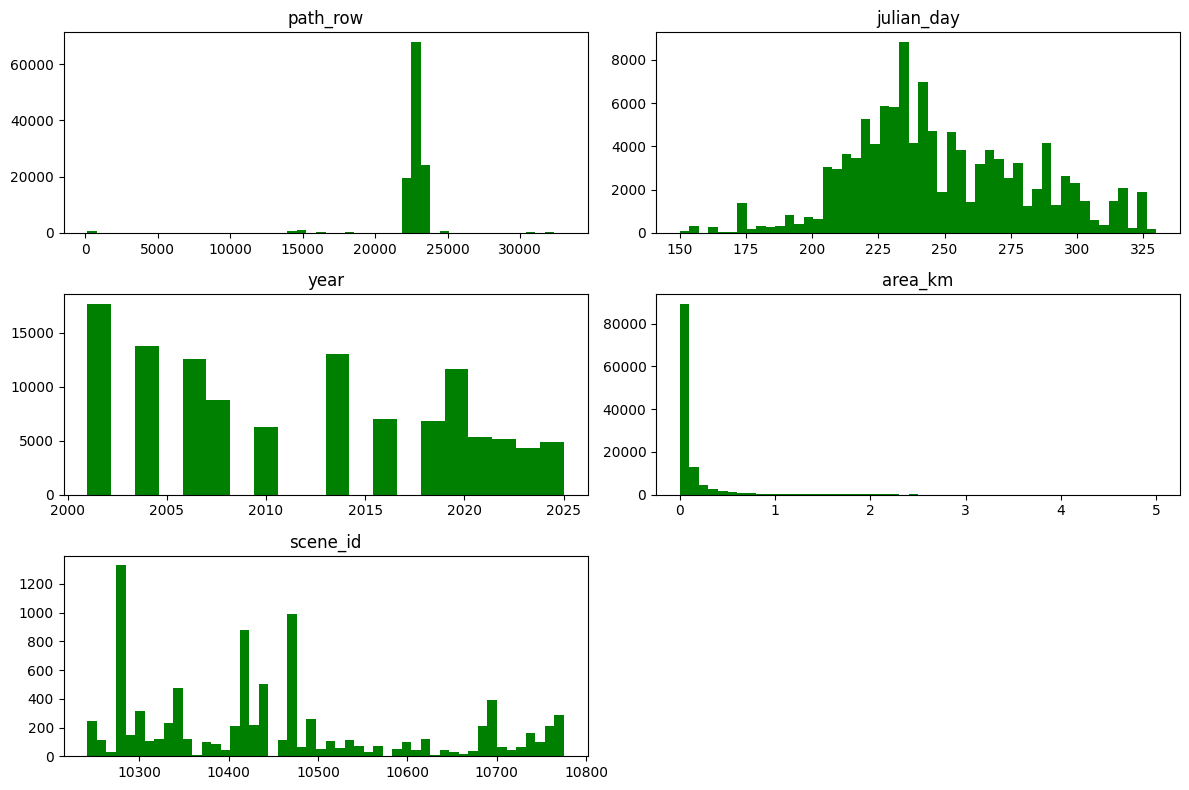

In [36]:
plt.figure(figsize=(12, 8))

plt.subplot(3, 2, 1)
plt.hist(deforestation_df["path_row"], bins=50, color="green")
plt.title("path_row")


plt.subplot(3, 2, 2)
plt.hist(deforestation_df["julian_day"], bins=50, range=(150, 330), color="green")
plt.title("julian_day")


plt.subplot(3, 2, 3)
plt.hist(deforestation_df["year"], bins=20, range=(2001, 2025), color="green")
plt.title("year")


plt.subplot(3, 2, 4)
plt.hist(deforestation_df["area_km"], bins=50, range=(0, 5), color="green")
plt.title("area_km")


plt.subplot(3, 2, 5)
plt.hist(deforestation_df["scene_id"], bins=50, color="green")
plt.title("scene_id")

plt.tight_layout()
plt.show()

### beef_df

The histograms below show different distributions across the variables. year is spread across multiple years, while cattle_deforestation, co2 gross, and co2 net and fob are right-skewed, with most values grouped near zero and fewer higher values. land_use has a more spread-out distribution, but with right skewness, volume has most observations between 0.5 and 1.


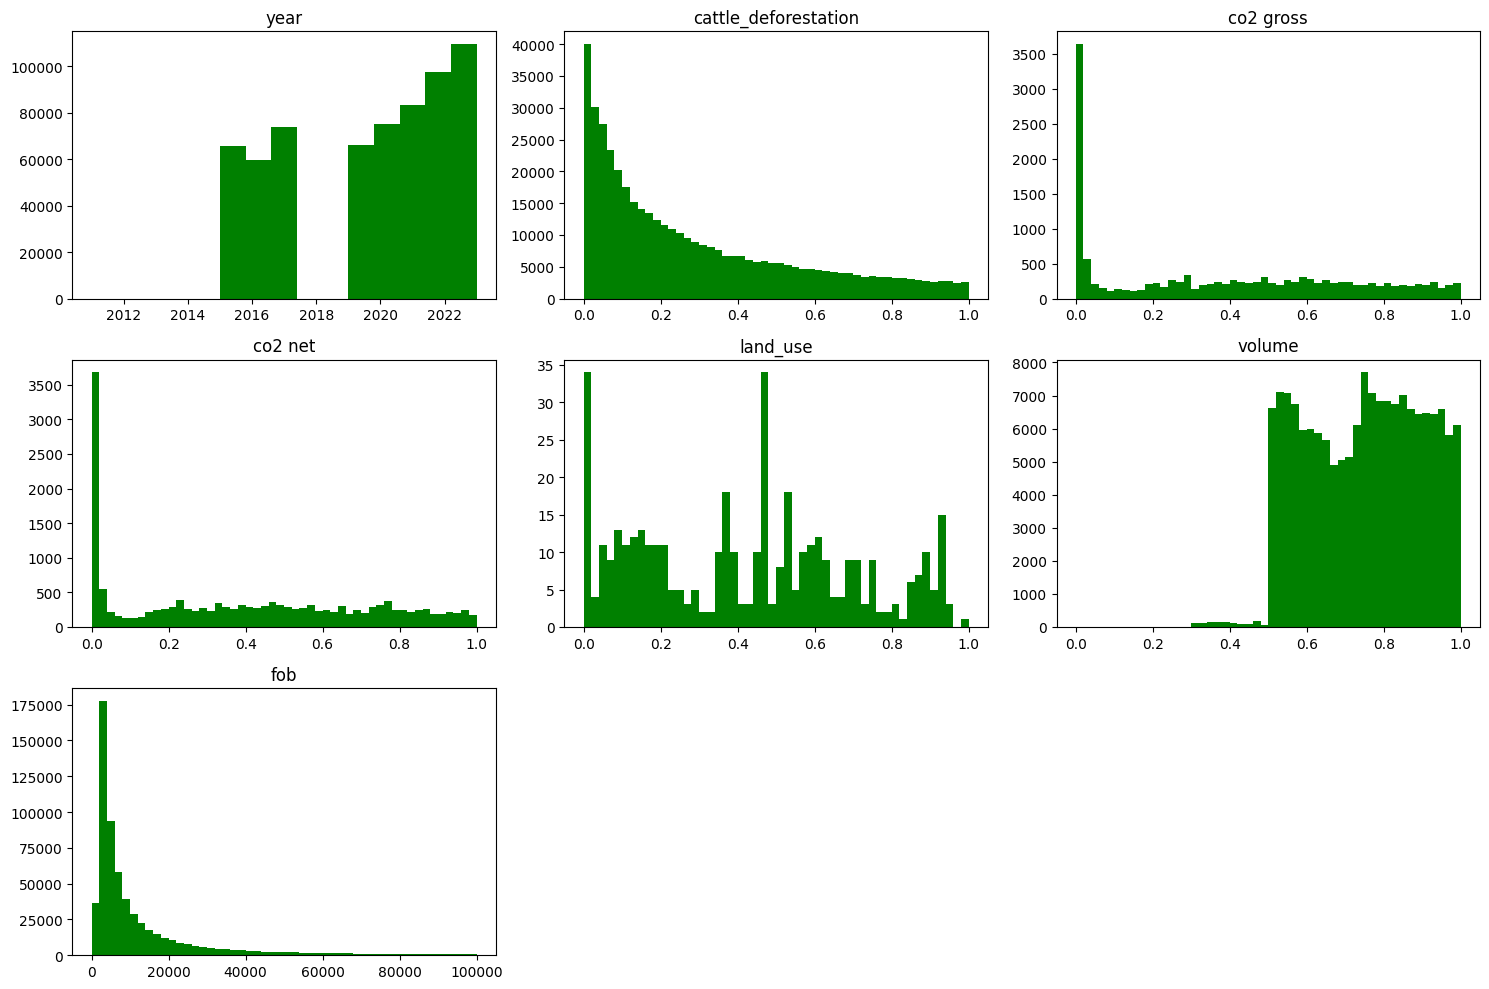

In [32]:
plt.figure(figsize=(15, 10))

plt.subplot(3, 3, 1)
plt.hist(beef_df["year"], bins=15, range=(2011, 2023), color = "green")
plt.title("year")

plt.subplot(3, 3, 2)
plt.hist(beef_df["cattle_deforestation_5_year_total_exposure"], bins=50, range=(0, 1), color = "green")
plt.title("cattle_deforestation")

plt.subplot(3, 3, 3)
plt.hist(beef_df["co2_gross_emissions_cattle_deforestation_5_year_total_exposure"], bins=50, range=(0, 1), color = "green")
plt.title("co2 gross")

plt.subplot(3, 3, 4)
plt.hist(beef_df["co2_net_emissions_cattle_deforestation_5_year_total_exposure"], bins=50, range=(0, 1), color = "green")
plt.title("co2 net")

plt.subplot(3, 3, 5)
plt.hist(beef_df["land_use"], bins=50, range=(0, 1), color = "green")
plt.title("land_use")

plt.subplot(3, 3, 6)
plt.hist(beef_df["volume"], bins=50, range=(0, 1), color = "green")
plt.title("volume")

plt.subplot(3, 3, 7)
plt.hist(beef_df["fob"], bins=50, range=(0, 100000),color = "green")
plt.title("fob")

plt.tight_layout()
plt.show()

### co2_df

The histograms show different distributions across the variables. Some variables, such as DEGRAD Area, SV CO2Emission, and DEGRAD CO2Emission, are highly right-skewed with most values close to zero, while variables like VR CO2 1stOrder, VR CO2 2ndOrder, NET 1st Order, and NET 2nd Order are more spread across the dataset.

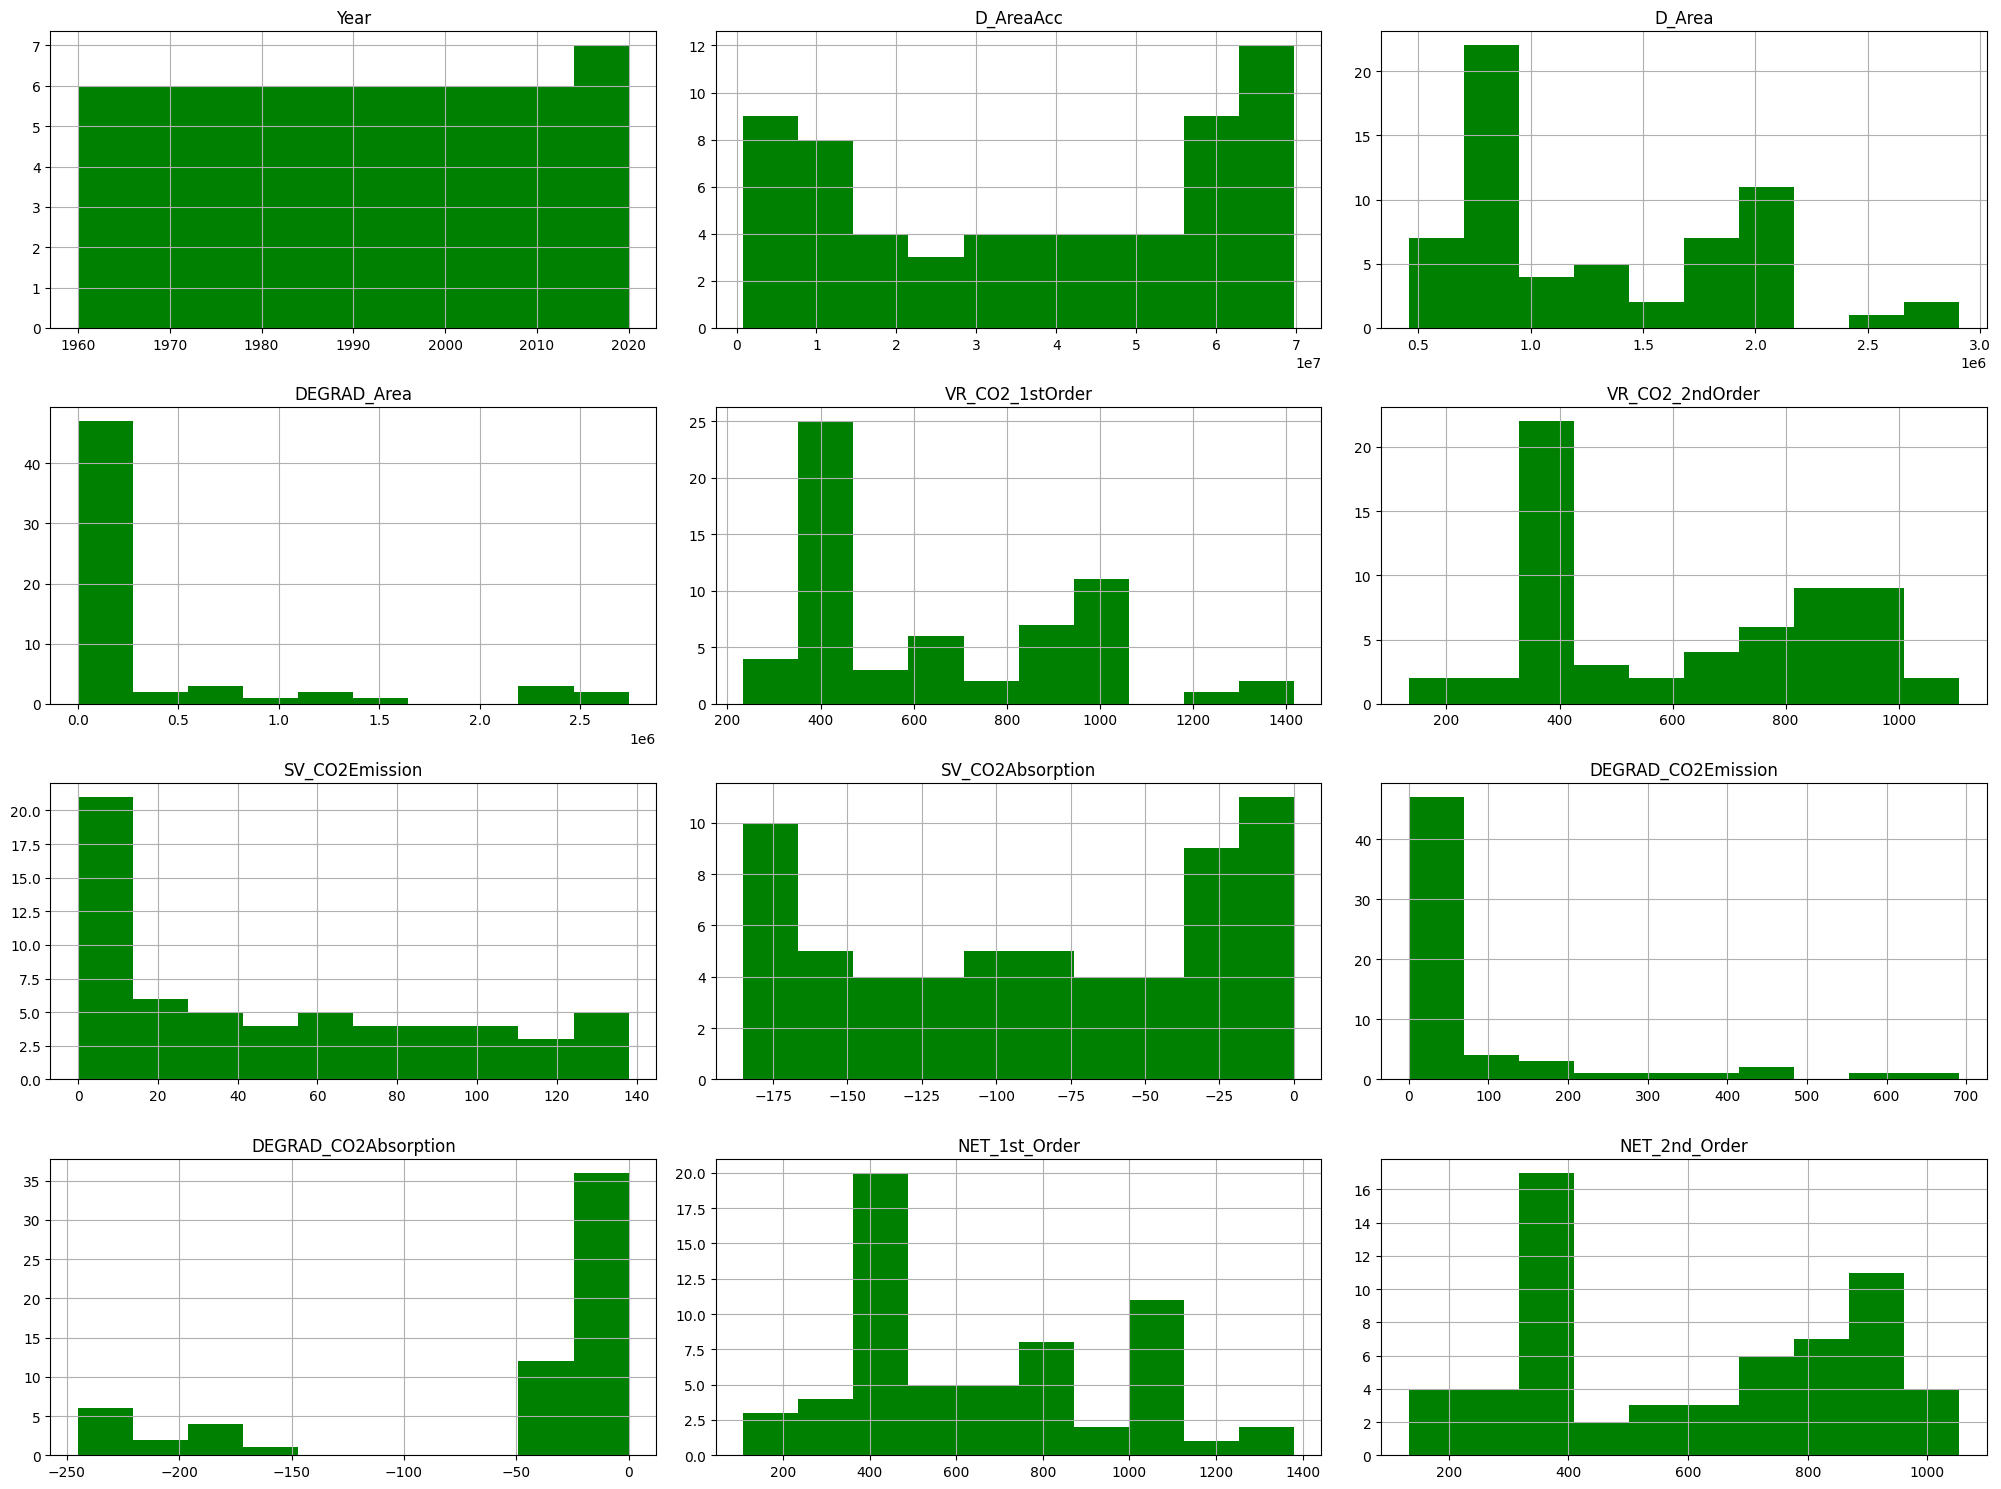

In [39]:
co2_df.hist(figsize=(20,15), color="green")
plt.tight_layout()
plt.show()

### Outliers
Boxplots were used to understand the distribution of the variables and identify extreme values across the datasets.
* Boxplot 1 shows that most deforestation values are very close to 0 km², with a few outliers reaching up to around 50 km², indicating a highly skewed distribution.
  
*  Boxplot 2 shows similar skewness across the beef-related variables, where most observations are concentrated near lower values while a few extreme outliers are present. Variables such as FOB, CO2 Gross, and CO2 Net contain very large values compared to the majority of the dataset, indicating high variability and presence of outliers.
  
* Boxplot 3 NET_2nd_Order shows a more balanced distribution, with values roughly between 130 and 1000 and a median around 650 making it easier to interpret typical values.

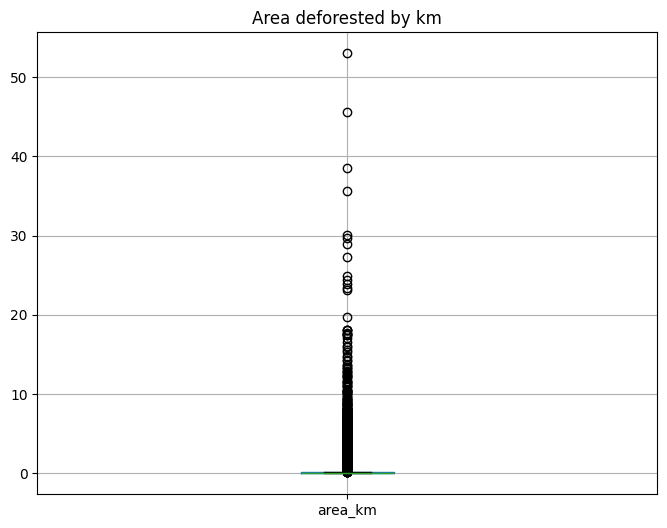

In [29]:
plt.figure(figsize=(8,6))
deforestation_df.boxplot(column=['area_km'])
plt.title('Area deforested by km')
plt.show()

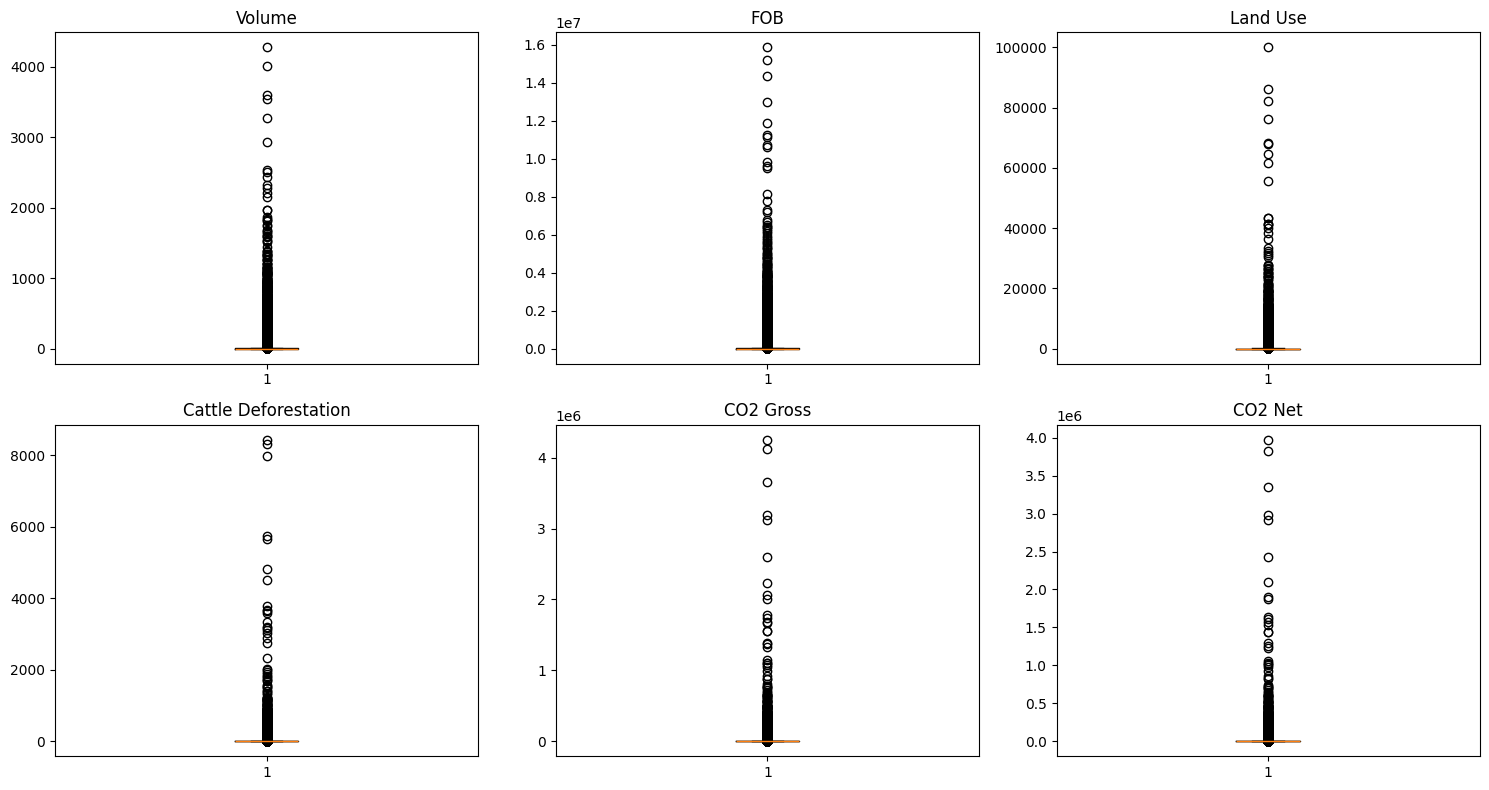

In [41]:
plt.figure(figsize=(15,8))

plt.subplot(2, 3, 1)
plt.boxplot(beef_df["volume"].dropna())
plt.title("Volume")

plt.subplot(2, 3, 2)
plt.boxplot(beef_df["fob"].dropna())
plt.title("FOB")


plt.subplot(2, 3, 3)
plt.boxplot(beef_df["land_use"].dropna())
plt.title("Land Use")


plt.subplot(2, 3, 4)
plt.boxplot(beef_df["cattle_deforestation_5_year_total_exposure"].dropna())
plt.title("Cattle Deforestation")


plt.subplot(2, 3, 5)
plt.boxplot(beef_df["co2_gross_emissions_cattle_deforestation_5_year_total_exposure"].dropna())
plt.title("CO2 Gross")


plt.subplot(2, 3, 6)
plt.boxplot(beef_df["co2_net_emissions_cattle_deforestation_5_year_total_exposure"].dropna())
plt.title("CO2 Net")

plt.tight_layout()
plt.show()

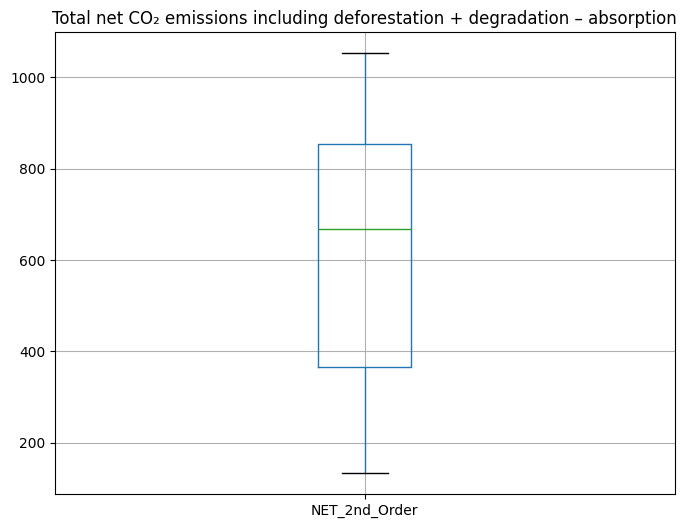

In [31]:
plt.figure(figsize=(8,6))
co2_df.boxplot(column=['NET_2nd_Order' ])
plt.title('Total net CO₂ emissions including deforestation + degradation – absorption')
plt.show()

### CHECKING FEATURES RELATIONSHIP
These scatter plots were use to explore how variables behave over time and how they relate to each other. In the first plot year vs area, most values stay below 20 km², with only one clear outlier reaching just above 45 km² around the early 2000s, while more recent years show lower and more stable values. station and CO₂, with values up to around 100,000, and deforestation reaching roughly 8,000.

In [32]:
#!pip install --upgrade plotly

In [33]:
# fig_2d=px.scatter(deforestation_df,
#            x='year',
#            y='area_km',
#            color='year',
#            size='year',
#            hover_data=['area_km'])
# fig_2d.show()


In the scatter matrix, there is a strong linear relationship between Volume and FOB, reaching up to about 4,000 (volume) and 15M (FOB). Land use also shows a positive relationship with defore.CO₂ gross and net emissions are highly correlated, both exceeding 4 million

In [34]:
# fig_matrix = px.scatter_matrix(
#     beef_df,
#     dimensions=[
#         'volume',
#         'fob',
#         'cattle_deforestation_5_year_total_exposure',
#         'land_use',
#         'co2_gross_emissions_cattle_deforestation_5_year_total_exposure',
#         'co2_net_emissions_cattle_deforestation_5_year_total_exposure'
#     ],
#     labels={
#         'cattle_deforestation_5_year_total_exposure': 'Deforestation_5year',
#         'volume': 'Volume',
#         'fob': 'FOB',
#         'land_use': 'land',
#         'co2_gross_emissions_cattle_deforestation_5_year_total_exposure': 'co2_gross',
#         'co2_net_emissions_cattle_deforestation_5_year_total_exposure': 'co2_net'
#     },
#     color='year'
# )

# fig_matrix.update_layout( width=1000, height=1000)
# fig_matrix.show()

In the final plot, NET CO₂ emissions increase from around 200 in the 1960s to peaks of about 1,100 in the early 2000s, then decline and fluctuate in recent years between 200 and 80

In [35]:
# fig_2d=px.scatter(co2_df,
#            x='Year',
#            y='NET_2nd_Order',
#            color='Year',
#            size='Year',
#            hover_data=['NET_2nd_Order'])
# fig_2d.show()

# Simple aggregations
Simple aggregations were used to track how values change over time. Deforestation was highest early on around 3100 km² in 2002 and decreased later. In contrast, beef volume increased from about 223k in 2011 to 690k in 2023, and FOB reached over 2.7 billion, showing economic growth. CO₂ net emissions also rose significantly, reaching over 120 million.

In [30]:
deforestation_df.groupby("year")["area_km"].sum()

year
2002    3103.592468
2004    2760.037609
2006    1882.480304
2008    1163.067041
2010     756.332634
2013    1054.657118
2014     642.272501
2016    1029.121123
2018    1112.089110
2019     679.653633
2020     668.548375
2021     719.338490
2022     726.329228
2023     584.821165
2024     554.039276
Name: area_km, dtype: float64

In [31]:
beef_df.groupby("year")["volume"].sum()

year
2011    223371.898449
2012    428169.688837
2013    609881.468995
2014    599552.803322
2015    483791.314941
2016    462177.754768
2017    582599.476231
2019    505467.315764
2020    624532.444719
2021    502095.163737
2022    636842.113125
2023    690665.151333
Name: volume, dtype: float64

In [32]:
beef_df.groupby("year")["fob"].sum()

year
2011    7.301116e+08
2012    1.414814e+09
2013    1.934537e+09
2014    1.964155e+09
2015    1.387633e+09
2016    1.206347e+09
2017    1.598278e+09
2019    1.648547e+09
2020    2.137257e+09
2021    1.931284e+09
2022    2.696068e+09
2023    2.744971e+09
Name: fob, dtype: float64

In [33]:
beef_df.groupby("year")["co2_net_emissions_cattle_deforestation_5_year_total_exposure"].sum()

year
2011    0.000000e+00
2012    0.000000e+00
2013    0.000000e+00
2014    0.000000e+00
2015    9.314900e+07
2016    8.958171e+07
2017    9.943585e+07
2019    9.643755e+07
2020    1.170607e+08
2021    9.392564e+07
2022    1.156021e+08
2023    1.266708e+08
Name: co2_net_emissions_cattle_deforestation_5_year_total_exposure, dtype: float64

## EDA Conclusion

After conducting an exploratory data analysis (EDA) on the three datasets, it was determined that integrating all of them would not be appropriate for the scope of this project. The primary objective is to predict CO₂ emissions specifically associated with beef production.

The beef dataset alone contains all the relevant features required to support this objective, including variables directly linked to cattle-related deforestation and emissions. Although we initially considered incorporating the area_km variable from the deforestation dataset and the CO₂ column from the emissions dataset, further analysis revealed a critical limitation.

Deforestation and CO₂ datasets represent aggregate values, containing multiple sources beyond beef production. As a result, including these variables would introduce noise and reduce the focus of the model, as they do not isolate deforestation or emissions caused only by cattle-related activities.

Therefore, to maintain the  relevance of the predictive model, the decision was made to rely exclusively on the beef dataset, which provides targeted and domain-specific information aligned with the research objective.



# DATA PREPARATION

### Missing values approach

For the data preparation stage. We used two different techniques, and in each of them we did 4 different models. 

* The first technique, we dropped all the missing values using drop.na before the modelling.
  
* The second technique we used median imputation to fill in the missing values.

In [34]:
beef_df.isnull().sum()

year                                                                   0
country_of_production                                                  0
biome                                                                  0
state_of_production                                                    0
state_of_production_trase_id                                           0
municipality_of_production                                             0
municipality_of_production_trase_id                                    0
logistics_hub                                                          0
product_type                                                           0
port_of_export                                                         0
exporter                                                               0
exporter_group                                                         0
zero_deforestation_brazil_beef                                         0
forest_500_beef                                    

### Invalid Entries

Removing Invalid entries
In this section, after analysing the data during the EDA phase, special characters were identified and removed using the .replace() function

In [42]:
beef_df["importer"] = beef_df["importer"].astype(str).str.replace('&#', '')

In [43]:
beef_df["importer"] = beef_df["importer"].astype(str).str.replace('"', '')

In [5]:
beef_df["importer"].astype(str).str.contains('"', na=False).sum()

0

In [44]:
beef_df["importer"].str.contains("&#", na=False).sum()

0

In [7]:
beef_df_median_Input = beef_df.copy()

In [8]:
beef_df_median_Input = beef_df_median_Input.fillna(beef_df_median_Input.median(numeric_only=True))

### Dropping Missing Values for "missing values" approach

In [9]:
beef_df = beef_df.dropna(subset=["land_use","cattle_deforestation_5_year_total_exposure", "co2_gross_emissions_cattle_deforestation_5_year_total_exposure", "co2_net_emissions_cattle_deforestation_5_year_total_exposure" ])

In [7]:
beef_df.isnull().sum()

year                                                              0
country_of_production                                             0
biome                                                             0
state_of_production                                               0
state_of_production_trase_id                                      0
municipality_of_production                                        0
municipality_of_production_trase_id                               0
logistics_hub                                                     0
product_type                                                      0
port_of_export                                                    0
exporter                                                          0
exporter_group                                                    0
zero_deforestation_brazil_beef                                    0
forest_500_beef                                                   0
importer                                        

In [37]:
beef_df.shape

(630603, 26)

### Removing unecessary columns

We decided to remove the columns below because they do not provide meaningful information for the analysis. Some columns only contain IDs, the "country_of_production" contains only Brazil, and the biome column contains only AMAZONIA. In addition, the "import_group" column was removed because the "importer" column already provides the same information.



In [10]:
removing_columns = [
    "country_of_production",
    "biome",
    "country_of_production_trase_id",
    "state_of_production_trase_id",
    "municipality_of_production_trase_id",
    "importer_group"]

In [9]:
beef_df = beef_df.drop(columns=removing_columns)

In [10]:
beef_df.shape

(630603, 20)

### Label Encoding

We decided to use label encoding because the dataset is very large and contains a high number of categories and observations. Using other encoding methods would increase the complexity and require more computational resources, making them less feasible for this project.



In [41]:
beef_df.dtypes

year                                                                int64
state_of_production                                                   str
municipality_of_production                                            str
logistics_hub                                                         str
product_type                                                          str
port_of_export                                                        str
exporter                                                              str
exporter_group                                                        str
zero_deforestation_brazil_beef                                        str
forest_500_beef                                                       str
importer                                                              str
country_of_destination                                                str
economic_bloc                                                         str
country_of_destination_trase_id       

In [11]:
from sklearn.preprocessing import LabelEncoder
labelE = LabelEncoder()

for col in beef_df.select_dtypes(include='str').columns:
    beef_df[col] = labelE.fit_transform(beef_df[col])


In [12]:
beef_df.dtypes

year                                                                int64
state_of_production                                                 int32
municipality_of_production                                          int32
logistics_hub                                                       int32
product_type                                                        int32
port_of_export                                                      int32
exporter                                                            int32
exporter_group                                                      int32
zero_deforestation_brazil_beef                                      int32
forest_500_beef                                                     int32
importer                                                            int32
country_of_destination                                              int32
economic_bloc                                                       int32
country_of_destination_trase_id       

# MODELING

### Created Models with dropping missing values approach.

### KNN (K-Nearest Neighbors) 

In [10]:
# Dropped the "co2_gross" as Target variable (y) and "co2_net" due to correlation to co2_gross, KNN does not handle multicollinearity well.
X = beef_df.drop(columns=["co2_gross_emissions_cattle_deforestation_5_year_total_exposure", "co2_net_emissions_cattle_deforestation_5_year_total_exposure"])
y = beef_df["co2_gross_emissions_cattle_deforestation_5_year_total_exposure"]

In [11]:
# Splitted the dataset into the Training (80%) and Test (20%) 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

### Robust Scaler

We used RobustScaler because it removes the median and scales the data using the interquartile range (IQR) due to the presence of Outliers in this dataset.


In [14]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

# fit_transform learns the scaling values from the training data (X_train) and transform applies the scaling to the data (X_test)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
knn = KNeighborsRegressor()

# Defined hyperparameters to test KNN model
param_grid = {
    "n_neighbors": [11, 15, 21, 31],
    "weights": ["uniform", "distance"],
}

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=2,
    scoring="r2",
    n_jobs=4
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
Best CV Score: 0.31132121832234305


In [16]:
from sklearn.neighbors import KNeighborsRegressor

# Created the model with hyperparameters selected by GridSearchCV
knn = KNeighborsRegressor(n_neighbors=11, weights="distance")

# Trained the model using the scaled training data
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### Predict
KNN model checks at the nearest neighbors of each data point and predicts a value based on those neighbors.

In [17]:
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

In [18]:
from sklearn.metrics import mean_absolute_error, r2_score

print("Train Evaluation")

print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("R2:", r2_score(y_train, y_train_pred))

print('Test Evaluation')
print('MAE:', mean_absolute_error(y_test, y_test_pred))
print('R2:', r2_score(y_test, y_test_pred))

Train Evaluation
MAE: 0.0
R2: 1.0
Test Evaluation
MAE: 188.6147839402892
R2: 0.9345513004009368


In [19]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(knn, X, y, cv=5, scoring="r2")

print("R2 scores:", scores)
print("Mean R2:", scores.mean())

R2 scores: [0.11862516 0.29133696 0.50809894 0.52653178 0.53910878]
Mean R2: 0.39674032439247303


### Random Forest

In [22]:
X = beef_df.drop(columns=['co2_gross_emissions_cattle_deforestation_5_year_total_exposure'])
y = beef_df['co2_gross_emissions_cattle_deforestation_5_year_total_exposure']

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [25]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()

param_grid = {
    "n_estimators": [80, 100, 120],
    "max_depth": [6, 8, 10],
    "min_samples_split": [2, 4, 6],
    "min_samples_leaf": [3, 4, 5],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=2,
    scoring="r2",
    n_jobs=4
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 100}
Best CV Score: 0.9016947206541318


In [26]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(max_depth=8, max_features="log2", min_samples_leaf=3, min_samples_split=6, n_estimators=100)

rfr.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### Predict
Random Forest Regression model predicts values by combining the results from 100 decision trees and averaging their predictions.

In [27]:
y_train_pred = rfr.predict(X_train)
y_test_pred = rfr.predict(X_test)

In [28]:
from sklearn.metrics import mean_absolute_error, r2_score

print('Train Evaluation')
print('MAE:', mean_absolute_error(y_train, y_train_pred))
print('R2:', r2_score(y_train, y_train_pred))

print('Test Evaluation')
print('MAE:', mean_absolute_error(y_test, y_test_pred))
print('R2:', r2_score(y_test, y_test_pred))

Train Evaluation
MAE: 409.7207326918228
R2: 0.9583836260068684
Test Evaluation
MAE: 425.5526206764016
R2: 0.8891416138384185


In [29]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rfr, X, y, cv=5, scoring="r2")

print("R2 scores:", scores)
print("Mean R2:", scores.mean())

R2 scores: [0.89169591 0.96016454 0.88348799 0.97768007 0.93046296]
Mean R2: 0.9286982929830332


## Partial Least Squares Regression

In [20]:
X = beef_df.drop(columns=['co2_gross_emissions_cattle_deforestation_5_year_total_exposure'])
y = beef_df['co2_gross_emissions_cattle_deforestation_5_year_total_exposure']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
from sklearn.cross_decomposition import PLSRegression

pls_model = PLSRegression(n_components=3)

In [25]:
pls_model.fit(X_train_scaled, y_train)

,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",3
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06
,"copy copy: bool, default=TrueWhether to copy `X` and `y` in :term:`fit` before applying centering,and potentially scaling. If `False`, these operations will be doneinplace, modifying both arrays.",True


### Predict

PLS Regression model predicts values by finding relationships between the input features and target variable using latent components.

In [26]:
y_train_pred = pls_model.predict(X_train_scaled)
y_test_pred = pls_model.predict(X_test_scaled)

In [27]:
from sklearn.metrics import mean_absolute_error, r2_score

print('Train Evaluation')
print('MAE:', mean_absolute_error(y_train, y_train_pred))
print('R2:', r2_score(y_train, y_train_pred))

print('Test Evaluation')
print('MAE:', mean_absolute_error(y_test, y_test_pred))
print('R2:', r2_score(y_test, y_test_pred))

Train Evaluation
MAE: 306.9352649910467
R2: 0.994457747752746
Test Evaluation
MAE: 301.5873498495705
R2: 0.9958158580642327


In [29]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pls_model, X, y, cv=5, scoring="r2")

print("R2 scores:", scores)
print("Mean R2:", scores.mean())

R2 scores: [0.99599986 0.99540643 0.9932031  0.99331451 0.99360741]
Mean R2: 0.9943062643983506


# Linear Regression

In [13]:
X = beef_df.drop(columns=['co2_gross_emissions_cattle_deforestation_5_year_total_exposure', 'co2_net_emissions_cattle_deforestation_5_year_total_exposure' ])
y = beef_df['co2_gross_emissions_cattle_deforestation_5_year_total_exposure']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [16]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Predict 

Linear Regression model predicts values by finding the best linear relationship between the input features and target variable.

In [18]:
y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)

In [19]:
from sklearn.metrics import mean_absolute_error, r2_score

print('Train Evaluation')
print('MAE:', mean_absolute_error(y_train, y_train_pred))
print('R2:', r2_score(y_train, y_train_pred))

print('Test Evaluation')
print('MAE:', mean_absolute_error(y_test, y_test_pred))
print('R2:', r2_score(y_test, y_test_pred))

Train Evaluation
MAE: 354.2397588032629
R2: 0.9825954907047206
Test Evaluation
MAE: 342.1270912190618
R2: 0.9888692051793163


In [21]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(lr_model, X, y, cv=5, scoring="r2")

print("R2 scores:", scores)
print("Mean R2:", scores.mean())

R2 scores: [0.98783307 0.9813217  0.98466933 0.97798407 0.96280324]
Mean R2: 0.9789222803777804


# Missing Values using Imputation with Median

In [11]:
beef_df_median_Input

,year,country_of_production,biome,state_of_production,state_of_production_trase_id,municipality_of_production,municipality_of_production_trase_id,logistics_hub,product_type,port_of_export,...,country_of_destination,economic_bloc,country_of_production_trase_id,country_of_destination_trase_id,cattle_deforestation_5_year_total_exposure,co2_gross_emissions_cattle_deforestation_5_year_total_exposure,co2_net_emissions_cattle_deforestation_5_year_total_exposure,land_use,volume,fob
0,2011,BRAZIL,AMAZONIA,ACRE,BR-12,BUJARI,BR-1200138,UNKNOWN,BEEF OFFALS,SANTOS,...,CHINA (HONG KONG),CHINA (HONG KONG),BR,HK,0.440201,169.744781,153.736787,28.407606,0.689217,2763.220500
1,2011,BRAZIL,AMAZONIA,ACRE,BR-12,RIO BRANCO,BR-1200401,UNKNOWN,BEEF OFFALS,SANTOS,...,CHINA (HONG KONG),CHINA (HONG KONG),BR,HK,0.440201,169.744781,153.736787,28.407606,0.975922,3912.684851
2,2011,BRAZIL,AMAZONIA,ACRE,BR-12,SENADOR GUIOMARD,BR-1200450,UNKNOWN,BEEF OFFALS,SANTOS,...,CHINA (HONG KONG),CHINA (HONG KONG),BR,HK,0.440201,169.744781,153.736787,28.407606,0.697649,2797.025472
3,2011,BRAZIL,AMAZONIA,AMAZONAS,BR-13,BOCA DO ACRE,BR-1300706,UNKNOWN,BEEF OFFALS,SANTOS,...,CHINA (HONG KONG),CHINA (HONG KONG),BR,HK,0.440201,169.744781,153.736787,28.407606,11.786114,39216.614533
4,2011,BRAZIL,AMAZONIA,AMAZONAS,BR-13,LABREA,BR-1302405,JARU,BEEF BONELESS,ITAJAA,...,RUSSIAN FEDERATION,RUSSIAN FEDERATION,BR,RU,0.440201,169.744781,153.736787,28.407606,1.119702,3395.156400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
839722,2023,BRAZIL,AMAZONIA,TOCANTINS,BR-17,XAMBIOA,BR-1722107,UNKNOWN,BEEF OFFALS,PARANAGUA,...,CONGO DEMOCRATIC REPUBLIC OF THE,CONGO DEMOCRATIC REPUBLIC OF THE,BR,CD,0.043196,17.361306,15.777227,9.799689,0.511401,1438.796896
839723,2023,BRAZIL,AMAZONIA,TOCANTINS,BR-17,XAMBIOA,BR-1722107,UNKNOWN,BEEF OFFALS,SANTOS,...,RUSSIAN FEDERATION,RUSSIAN FEDERATION,BR,RU,0.072477,29.130019,26.472139,16.442606,0.858064,2414.114511
839724,2023,BRAZIL,AMAZONIA,TOCANTINS,BR-17,XAMBIOA,BR-1722107,UNKNOWN,BEEF OFFALS,SANTOS,...,RUSSIAN FEDERATION,RUSSIAN FEDERATION,BR,RU,0.047195,18.968805,17.238054,10.707051,0.558752,1703.295442
839725,2023,BRAZIL,AMAZONIA,TOCANTINS,BR-17,XAMBIOA,BR-1722107,UNKNOWN,BEEF OFFALS,SANTOS,...,LIBERIA,LIBERIA,BR,LR,0.044279,17.796811,16.172995,10.045512,0.524229,1474.888787


In [12]:
beef_df_median_Input.isnull().sum()

year                                                              0
country_of_production                                             0
biome                                                             0
state_of_production                                               0
state_of_production_trase_id                                      0
municipality_of_production                                        0
municipality_of_production_trase_id                               0
logistics_hub                                                     0
product_type                                                      0
port_of_export                                                    0
exporter                                                          0
exporter_group                                                    0
zero_deforestation_brazil_beef                                    0
forest_500_beef                                                   0
importer                                        

In [27]:
beef_df_median_Input.dtypes

year                                                                int64
state_of_production                                                 int32
municipality_of_production                                          int32
logistics_hub                                                       int32
product_type                                                        int32
port_of_export                                                      int32
exporter                                                            int32
exporter_group                                                      int32
zero_deforestation_brazil_beef                                      int32
forest_500_beef                                                     int32
importer                                                            int32
country_of_destination                                              int32
economic_bloc                                                       int32
country_of_destination_trase_id       

In [14]:
from sklearn.preprocessing import LabelEncoder
labelE = LabelEncoder()

for col in beef_df_median_Input.select_dtypes(include='str').columns:
    beef_df_median_Input[col] = labelE.fit_transform(beef_df_median_Input[col])

In [15]:
beef_df_median_Input.dtypes

year                                                                int64
country_of_production                                               int32
biome                                                               int32
state_of_production                                                 int32
state_of_production_trase_id                                        int32
municipality_of_production                                          int32
municipality_of_production_trase_id                                 int32
logistics_hub                                                       int32
product_type                                                        int32
port_of_export                                                      int32
exporter                                                            int32
exporter_group                                                      int32
zero_deforestation_brazil_beef                                      int32
forest_500_beef                       

In [16]:
beef_df_median_Input.shape

(839727, 26)

In [17]:
removing_columns = [
    'country_of_production',
    'biome',
    'country_of_production_trase_id',
    'state_of_production_trase_id',
    'municipality_of_production_trase_id',
    'importer_group'
]

beef_df_median_Input = beef_df_median_Input.drop(columns=removing_columns)

In [18]:
beef_df_median_Input.shape

(839727, 20)

In [19]:
beef_df_median_Input

,year,state_of_production,municipality_of_production,logistics_hub,product_type,port_of_export,exporter,exporter_group,zero_deforestation_brazil_beef,forest_500_beef,importer,country_of_destination,economic_bloc,country_of_destination_trase_id,cattle_deforestation_5_year_total_exposure,co2_gross_emissions_cattle_deforestation_5_year_total_exposure,co2_net_emissions_cattle_deforestation_5_year_total_exposure,land_use,volume,fob
0,2011,0,64,100,3,29,122,121,6,7,2320,25,24,51,0.440201,169.744781,153.736787,28.407606,0.689217,2763.220500
1,2011,0,249,100,3,29,122,121,6,7,2320,25,24,51,0.440201,169.744781,153.736787,28.407606,0.975922,3912.684851
2,2011,0,304,100,3,29,122,121,6,7,2320,25,24,51,0.440201,169.744781,153.736787,28.407606,0.697649,2797.025472
3,2011,1,49,100,3,29,122,121,6,7,5586,25,24,51,0.440201,169.744781,153.736787,28.407606,11.786114,39216.614533
4,2011,1,158,44,1,17,99,99,6,7,5212,98,82,104,0.440201,169.744781,153.736787,28.407606,1.119702,3395.156400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
839722,2023,7,339,100,3,22,102,102,1,2,6762,29,28,19,0.043196,17.361306,15.777227,9.799689,0.511401,1438.796896
839723,2023,7,339,100,3,29,125,123,4,3,3609,98,82,104,0.072477,29.130019,26.472139,16.442606,0.858064,2414.114511
839724,2023,7,339,100,3,29,125,123,4,3,5223,98,82,104,0.047195,18.968805,17.238054,10.707051,0.558752,1703.295442
839725,2023,7,339,100,3,29,125,123,4,3,7198,66,56,72,0.044279,17.796811,16.172995,10.045512,0.524229,1474.888787


### KNN - Median Imputation

In [45]:
X = beef_df_median_Input.drop(columns=['co2_gross_emissions_cattle_deforestation_5_year_total_exposure', 'co2_net_emissions_cattle_deforestation_5_year_total_exposure'])
y = beef_df_median_Input['co2_gross_emissions_cattle_deforestation_5_year_total_exposure']

In [46]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [47]:
from sklearn.decomposition import PCA

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [48]:
knn = KNeighborsRegressor()

param_grid = {
    "n_neighbors": [11, 15, 21, 31],
    "weights": ["uniform", "distance"]
}

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=2,
    scoring="r2",
    n_jobs=4
)

grid_search.fit(X_train_pca, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}
Best CV Score: 0.9104989691848875


In [49]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=11, weights="distance")

knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [50]:
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

In [51]:
from sklearn.metrics import mean_absolute_error, r2_score
print("Train evaluation")
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("R2:", r2_score(y_train, y_train_pred))

print("Test evaluation")
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))

Train evaluation
MAE: 7.376414183040169e-05
R2: 0.9999999999999911
Test evaluation
MAE: 197.835876635816
R2: 0.9446896092912902


In [52]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(knn, X, y, cv=5, scoring="r2")

print("R2 scores for each fold:", scores)
print("Mean R2:", scores.mean())

R2 scores for each fold: [0.10568658 0.27761194 0.50317583 0.45513549 0.50529193]
Mean R2: 0.36938035440048617


### Random Forest - Median Imputation

In [57]:
X = beef_df_median_Input.drop(columns=['co2_gross_emissions_cattle_deforestation_5_year_total_exposure'])
y = beef_df_median_Input['co2_gross_emissions_cattle_deforestation_5_year_total_exposure']

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [59]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()

param_grid = {
    "n_estimators": [80, 100, 120],
    "max_depth": [6, 8, 10],
    "min_samples_split": [2, 4, 6],
    "min_samples_leaf": [3, 4, 5],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=2,
    scoring="r2",
    n_jobs=4
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 80}
Best CV Score: 0.9079160168186838


In [60]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(max_depth=10, max_features="sqrt", min_samples_leaf=3, min_samples_split=2, n_estimators=80 )

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",80
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [61]:
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

In [62]:
from sklearn.metrics import mean_absolute_error, r2_score
print("Train evaluation")
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("R2:", r2_score(y_train, y_train_pred))

print("\nTest evaluation")
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))

Train evaluation
MAE: 245.17251942433217
R2: 0.9610455723472308

Test evaluation
MAE: 264.2127339717292
R2: 0.893390572518161


In [63]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X, y, cv=5, scoring="r2")

print("R2 scores for each fold:", scores)
print("Mean R2:", scores.mean())

R2 scores for each fold: [0.86371284 0.96313178 0.90979547 0.98687284 0.95027766]
Mean R2: 0.9347581183772455


## Partial Least Squares Regression - Median Imputation


In [72]:
X = beef_df_median_Input.drop(columns=['co2_gross_emissions_cattle_deforestation_5_year_total_exposure'])
y = beef_df_median_Input['co2_gross_emissions_cattle_deforestation_5_year_total_exposure']

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [74]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [75]:
from sklearn.cross_decomposition import PLSRegression

pls_median_model = PLSRegression(n_components=3)

In [76]:
pls_median_model.fit(X_train_scaled, y_train)

,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",3
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06
,"copy copy: bool, default=TrueWhether to copy `X` and `y` in :term:`fit` before applying centering,and potentially scaling. If `False`, these operations will be doneinplace, modifying both arrays.",True


In [77]:
y_train_pred = pls_median_model.predict(X_train_scaled)
y_test_pred = pls_median_model.predict(X_test_scaled)

In [78]:
from sklearn.metrics import mean_absolute_error, r2_score

print('Train Evaluation')
print('MAE:', mean_absolute_error(y_train, y_train_pred))
print('R2:', r2_score(y_train, y_train_pred))

print('Test Evaluation')
print('MAE:', mean_absolute_error(y_test, y_test_pred))
print('R2:', r2_score(y_test, y_test_pred))

Train Evaluation
MAE: 287.58041681435293
R2: 0.9946477131783313
Test Evaluation
MAE: 282.58172147104995
R2: 0.99601369073945


In [79]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pls_model, X, y, cv=5, scoring="r2")

print("R2 scores:", scores)
print("Mean R2:", scores.mean())

R2 scores: [0.99603984 0.99568361 0.99338866 0.99346049 0.99357961]
Mean R2: 0.9944304412570825


# Linear Regression

In [20]:
X = beef_df_median_Input.drop(columns=['co2_gross_emissions_cattle_deforestation_5_year_total_exposure', 'co2_net_emissions_cattle_deforestation_5_year_total_exposure' ])
y = beef_df_median_Input['co2_gross_emissions_cattle_deforestation_5_year_total_exposure']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [22]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)

In [25]:
from sklearn.metrics import mean_absolute_error, r2_score

print('Train Evaluation')
print('MAE:', mean_absolute_error(y_train, y_train_pred))
print('R2:', r2_score(y_train, y_train_pred))

print('Test Evaluation')
print('MAE:', mean_absolute_error(y_test, y_test_pred))
print('R2:', r2_score(y_test, y_test_pred))

Train Evaluation
MAE: 287.3357052659435
R2: 0.985191283547144
Test Evaluation
MAE: 285.7744133228595
R2: 0.9741602285799593


In [26]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(lr_model, X, y, cv=5, scoring="r2")

print("R2 scores:", scores)
print("Mean R2:", scores.mean())

R2 scores: [0.         0.98811938 0.98129772 0.98168594 0.96417249]
Mean R2: 0.7830551048077357


In [28]:
from sklearn.model_selection import KFold,cross_val_score
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(lr_model, X, y, cv=cv, scoring="r2")

print("R2 scores:", scores)
print("Mean R2:", scores.mean())

R2 scores: [0.97416023 0.9862842  0.98746407 0.97957028 0.97656849]
Mean R2: 0.9808094545102868
